In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA

sns.set_style("whitegrid")

first 5 rows of dataset
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
Shape of dataset
(891, 15)
data types of columns
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fa

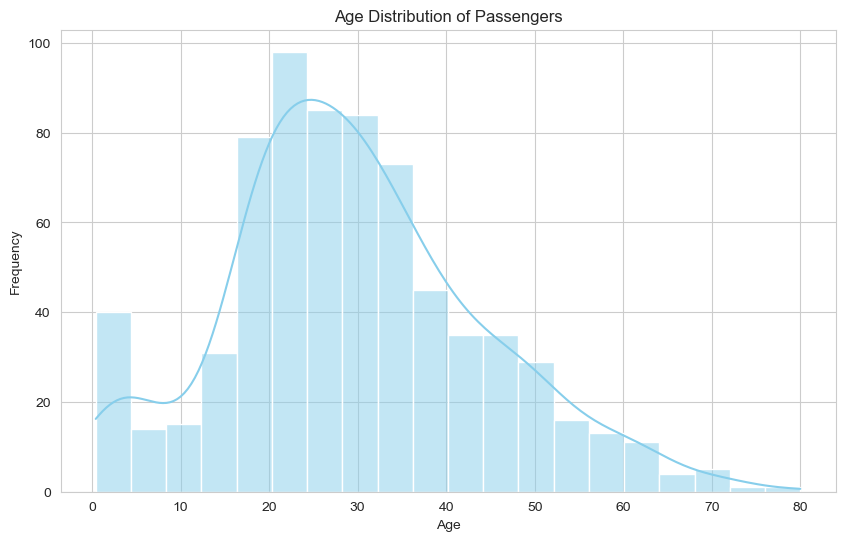

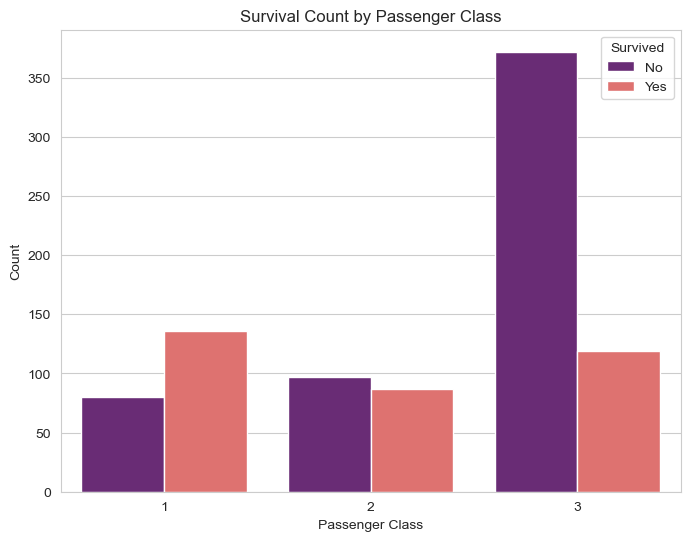

In [35]:
# TASK 1  
titanic = sns.load_dataset("titanic")
print("first 5 rows of dataset")
print(titanic.head())
print("Shape of dataset")
print(titanic.shape)
print("data types of columns")
print(titanic.dtypes)
num_cols = titanic.select_dtypes(include=['number']).columns.tolist()
cat_cols = titanic.select_dtypes(include=['object', 'category']).columns.tolist()
print("numeric columns", num_cols)
print("categoric columns", cat_cols)

print("Number of nan values by each column")
print(titanic.isnull().sum())
print("Percentage of nan values by each column")
print(titanic.isnull().mean() * 100)

print("Proportion of values in survived column")
print(titanic['survived'].value_counts(normalize=True) * 100)

plt.figure(figsize=(10, 6))
sns.histplot(titanic['age'].dropna(), kde=True, color='skyblue')
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8, 6))
sns.countplot(x='pclass', hue='survived', data=titanic, palette='magma')
plt.title('Survival Count by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

TASK 1 MARKDOWN

1. Age Distribution
Predominant Group: The majority of passengers were young adults, specifically in the 20–35 age range.

Demographic Spikes: There is a noticeable spike in the number of young children (ages 0–5), indicating many families were traveling.

Skewness: The distribution is right-skewed, with very few passengers over the age of 60.

2. Survival by Passenger Class
First Class (Class 1): This group had the highest survival probability. More people survived than perished in this category.

Second Class (Class 2): Survival and mortality rates were nearly equal, showing a moderate chance of rescue.

Third Class (Class 3): Although it was the most populated class, it suffered the highest number of fatalities. The vast majority of passengers in this class did not survive.

Key Conclusion
The visualizations clearly suggest that socio-economic status (Class) played a critical role in survival chances. While the ship's population was mostly young, being in a higher-tier class significantly increased the likelihood of being prioritized during the evacuation process.

In [36]:
# TASK 2.1
titanic['age'] = titanic['age'].fillna(titanic['age'].median())
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])
titanic = titanic.drop(columns="deck")

# TASK 2.2
le = LabelEncoder()
titanic['sex'] = le.fit_transform(titanic['sex'])
titanic = pd.get_dummies(titanic, columns=['embarked'])

# TASK 2.3
titanic["family_size"] = titanic["sibsp"] + titanic["parch"] + 1
titanic['is_alone'] = titanic['family_size'].apply(lambda x: 1 if x == 1 else 0)
titanic = titanic.drop(columns=["alive" , "who" , "adult_male" , "embark_town" , "class" , "alone"])
print(titanic)
for i in titanic.columns:
    if not pd.api.types.is_numeric_dtype(titanic[i]):
        print(f"Column '{i}' is NOT numeric. Type: {titanic[i].dtype}")

     survived  pclass  sex   age  sibsp  parch     fare  embarked_C  \
0           0       3    1  22.0      1      0   7.2500       False   
1           1       1    0  38.0      1      0  71.2833        True   
2           1       3    0  26.0      0      0   7.9250       False   
3           1       1    0  35.0      1      0  53.1000       False   
4           0       3    1  35.0      0      0   8.0500       False   
..        ...     ...  ...   ...    ...    ...      ...         ...   
886         0       2    1  27.0      0      0  13.0000       False   
887         1       1    0  19.0      0      0  30.0000       False   
888         0       3    0  28.0      1      2  23.4500       False   
889         1       1    1  26.0      0      0  30.0000        True   
890         0       3    1  32.0      0      0   7.7500       False   

     embarked_Q  embarked_S  family_size  is_alone  
0         False        True            2         0  
1         False       False            2 

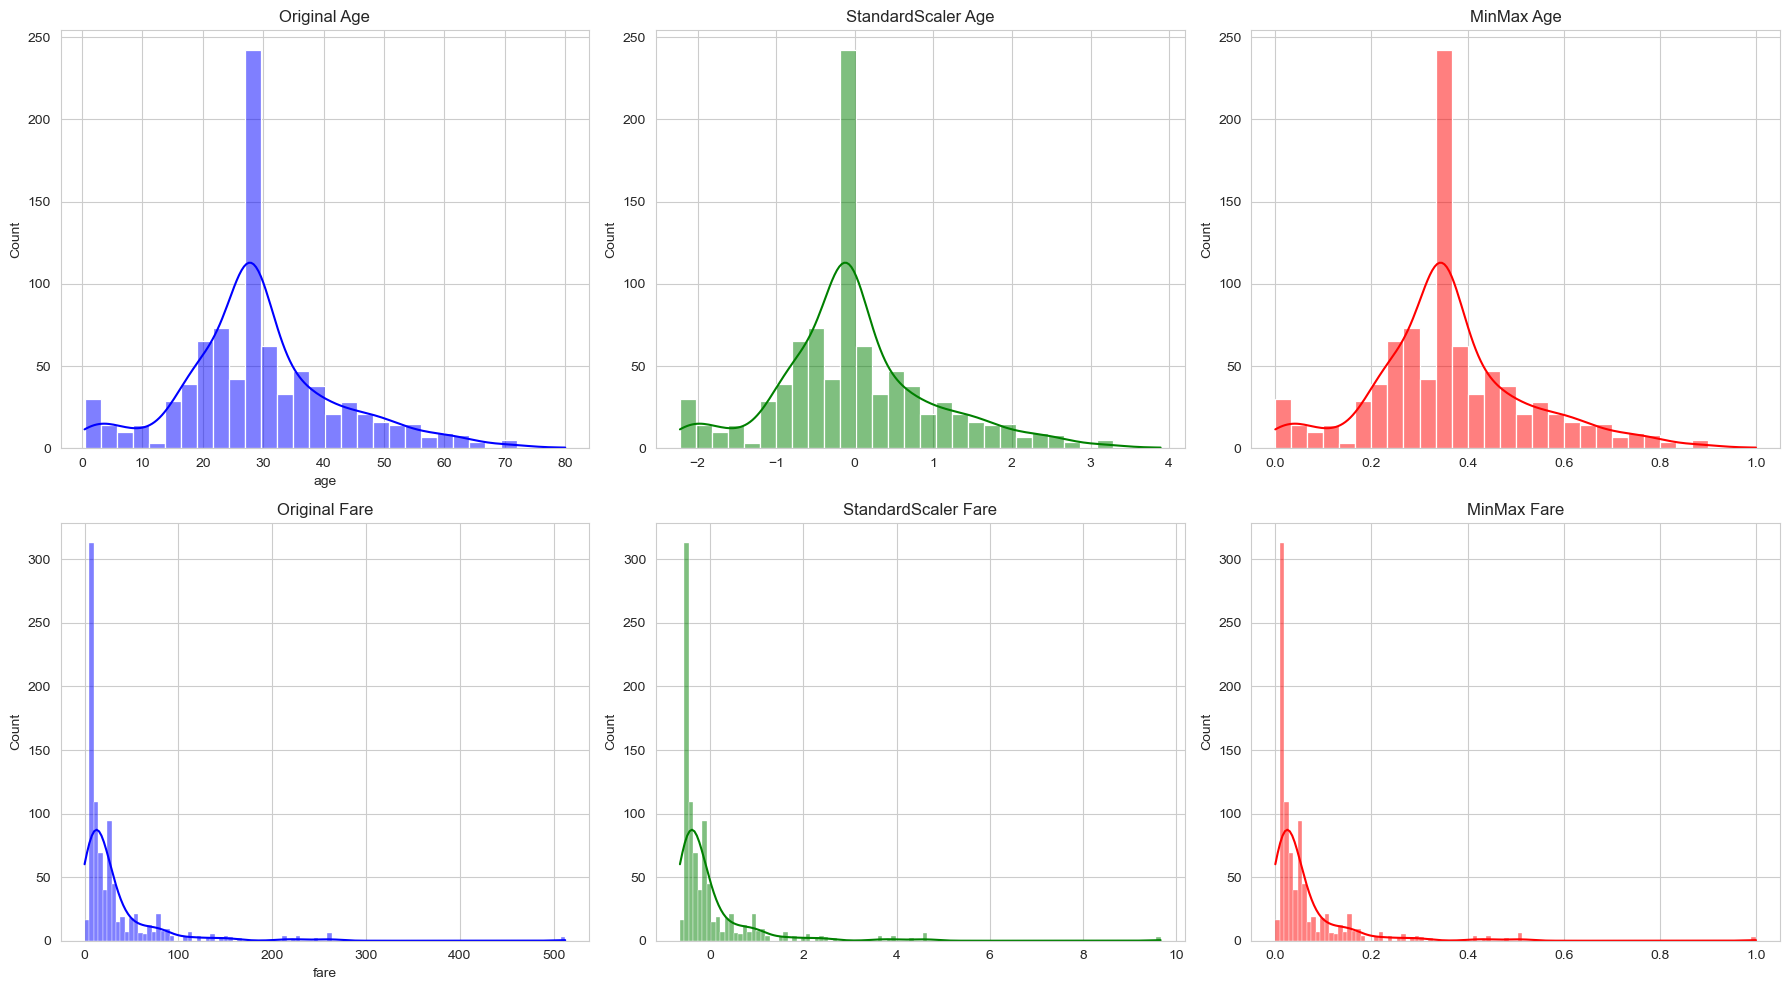

In [37]:
# TASK 3.1
# standart scaler
standart_scaler = StandardScaler()
standart_scaled_data = standart_scaler.fit_transform(titanic)
# minmax scaler
minmax_scaler = MinMaxScaler(feature_range=(0, 1))
minmax_scaled_data = minmax_scaler.fit_transform(titanic)

age_idx = titanic.columns.get_loc("age")
fare_idx = titanic.columns.get_loc("fare")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.histplot(titanic["age"], kde=True, ax=axes[0, 0], color="blue").set_title("Original Age")
sns.histplot(standart_scaled_data[:, age_idx], kde=True, ax=axes[0, 1], color="green").set_title("StandardScaler Age")
sns.histplot(minmax_scaled_data[:, age_idx], kde=True, ax=axes[0, 2], color="red").set_title("MinMax Age")

sns.histplot(titanic["fare"], kde=True, ax=axes[1, 0], color="blue").set_title("Original Fare")
sns.histplot(standart_scaled_data[:, fare_idx], kde=True, ax=axes[1, 1], color="green").set_title("StandardScaler Fare")
sns.histplot(minmax_scaled_data[:, fare_idx], kde=True, ax=axes[1, 2], color="red").set_title("MinMax Fare")

plt.tight_layout()
plt.show()

Comparison of Scaling Methods: StandardScaler vs. MinMaxScalerFeature scaling is a crucial preprocessing step in Machine Learning to ensure that features with large numerical ranges (like fare) do not dominate features with smaller ranges (like age).1. StandardScaler (Standardization)Formula:$$z = \frac{x - \mu}{\sigma}$$How it works: It transforms the data so that it has a mean of 0 and a standard deviation of 1.Key Characteristics:It does not bound values to a specific range (e.g., values can be negative or greater than 1).It maintains the shape of the original distribution but centers it around zero.It is generally more robust to outliers than MinMaxScaler because it doesn't compress all data into a tiny range based on extreme values.2. MinMaxScaler (Normalization)Formula:$$x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$$How it works: It scales the data to a fixed range, typically between 0 and 1.Key Characteristics:The minimum value of the feature becomes 0, and the maximum value becomes 1.It is very sensitive to outliers. If there is one extremely large value (like an expensive fare), the rest of the data will be squeezed into a very small range (e.g., between 0 and 0.01).It is preferred for algorithms that require features to be on the same scale and within a specific range, such as Neural Networks or K-Nearest Neighbors (KNN).

             survived    pclass       sex       age     sibsp     parch  \
survived     1.000000 -0.338481 -0.543351 -0.064910 -0.035322  0.081629   
pclass      -0.338481  1.000000  0.131900 -0.339898  0.083081  0.018443   
sex         -0.543351  0.131900  1.000000  0.081163 -0.114631 -0.245489   
age         -0.064910 -0.339898  0.081163  1.000000 -0.233296 -0.172482   
sibsp       -0.035322  0.083081 -0.114631 -0.233296  1.000000  0.414838   
parch        0.081629  0.018443 -0.245489 -0.172482  0.414838  1.000000   
fare         0.257307 -0.549500 -0.182333  0.096688  0.159651  0.216225   
embarked_C   0.168240 -0.243292 -0.082853  0.030248 -0.059528 -0.011069   
embarked_Q   0.003650  0.221009 -0.074115 -0.031415 -0.026354 -0.081228   
embarked_S  -0.149683  0.074053  0.119224 -0.006729  0.068734  0.060814   
family_size  0.016639  0.065997 -0.200988 -0.245619  0.890712  0.783111   
is_alone    -0.203367  0.135207  0.303646  0.171647 -0.584471 -0.583398   

                 fare  e

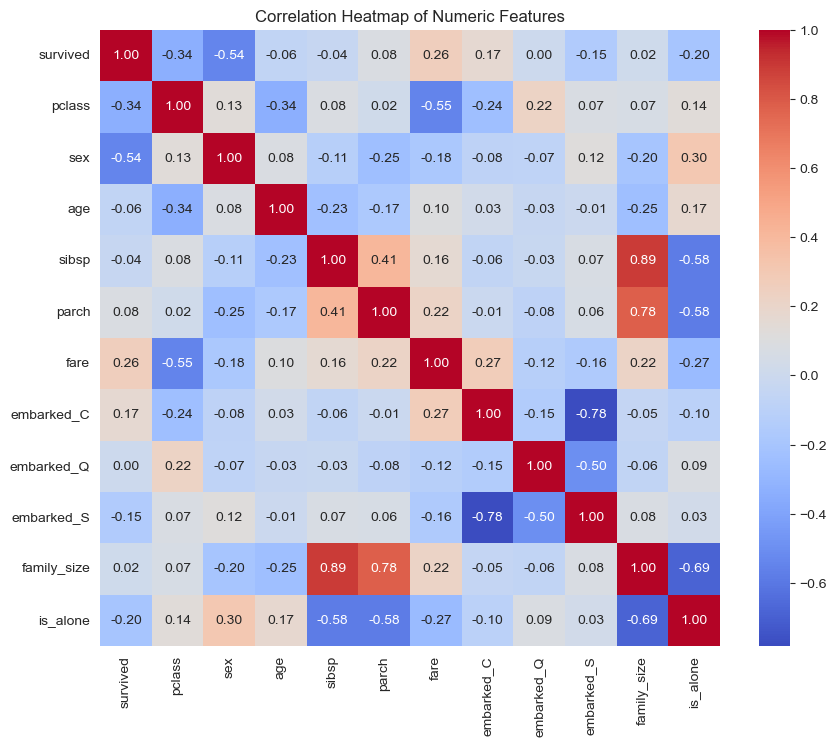

In [38]:
# TASK 3.2 
corr_matrix = titanic.corr(numeric_only=True)

print(corr_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

Which features have the strongest positive and negative correlations with survived?

positive correlations : fare , embarked_C 

negative correlations : pclass , sex , embarked_S , is_alone

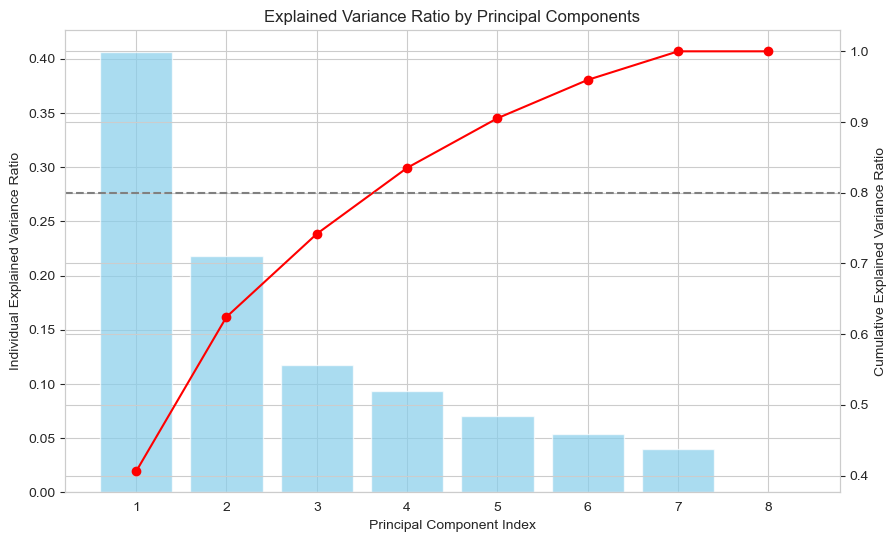

Number of components needed for 80% variance: 4


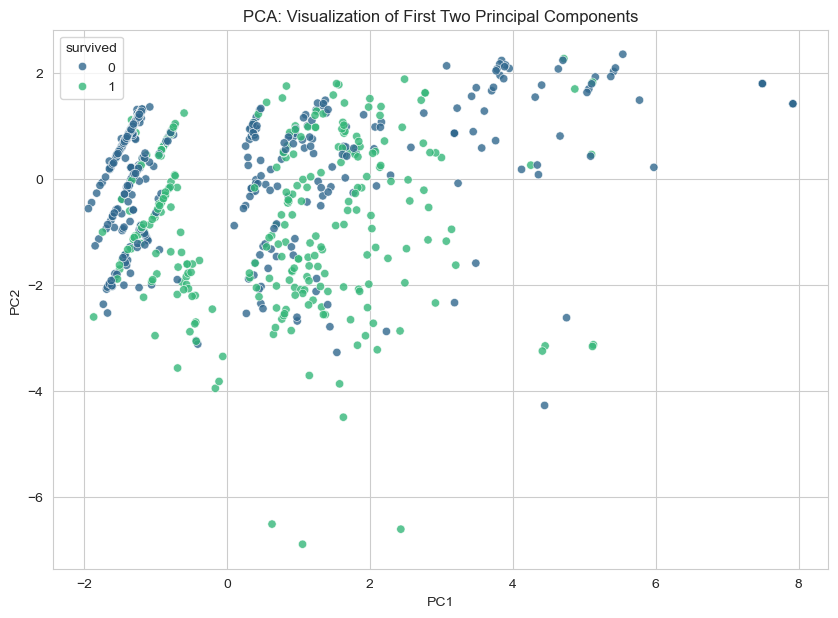

In [39]:
# TASK 4: Dimensionality Reduction

from sklearn.decomposition import PCA
import numpy as np

# 1. Prepare the data
# We use numeric columns that are actually meaningful for PCA
# Since you might have dropped columns in Task 3.2, let's ensure we use what's available
# or avoid dropping them in the previous step.
features_for_pca = titanic.select_dtypes(include=[np.number]).columns.tolist()
if 'survived' in features_for_pca:
    features_for_pca.remove('survived')

X = titanic[features_for_pca]
y = titanic['survived']

# 2. Standardize the data
# PCA is extremely sensitive to the scale of features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Fit PCA with all components to analyze variance
pca_all = PCA()
pca_all.fit(X_scaled)

explained_variance = pca_all.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# 4. Plot the explained variance
fig, ax1 = plt.subplots(figsize=(10, 6))

# Individual Explained Variance (Bar Chart)
ax1.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, color='skyblue', label='Individual')
ax1.set_xlabel('Principal Component Index')
ax1.set_ylabel('Individual Explained Variance Ratio')

# Cumulative Explained Variance (Line Chart)
ax2 = ax1.twinx()
ax2.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', color='red', label='Cumulative')
ax2.set_ylabel('Cumulative Explained Variance Ratio')
ax2.axhline(y=0.8, color='gray', linestyle='--') # 80% threshold line

plt.title('Explained Variance Ratio by Principal Components')
plt.show()

# Determine components for 80% variance
n_components_80 = np.argmax(cumulative_variance >= 0.8) + 1
print(f"Number of components needed for 80% variance: {n_components_80}")

# 5. Refit PCA with 2 components for visualization
pca_2 = PCA(n_components=2)
pca_2_results = pca_2.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=pca_2_results, columns=['PC1', 'PC2'])
pca_df['survived'] = y.values

# Scatter plot of the first two components
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='survived', data=pca_df, palette='viridis', alpha=0.8)
plt.title('PCA: Visualization of First Two Principal Components')
plt.show()

Does PCA help separate the classes?
Observation: Looking at the scatter plot of the first two Principal Components (PC1 vs PC2), the survivors (1) and non-survivors (0) are largely intermingled. There is no clear linear decision boundary or distinct clustering that separates the two groups.

Reasoning: PCA is an unsupervised technique that focuses on maximizing variance, not class separability. Since the variance in the Titanic dataset is driven more by passenger demographics and ticket pricing rather than just survival, the resulting components don't naturally group people by their survival status.

Should PCA be used as a preprocessing step for this dataset?
Recommendation: No, I would not use PCA as a primary preprocessing step for the Titanic dataset.

Justification:

Sufficiency of Original Features: The original feature space is already small (low-dimensional). Features like sex, pclass, and age have very high interpretability and strong individual correlations with survival.

Loss of Interpretability: PCA transforms these clear features into abstract components (PC1, PC2, etc.). For a dataset where understanding why someone survived is as important as the prediction itself, losing that direct link to the data is a disadvantage.

Complexity vs. Benefit: PCA is most effective for "High-Dimensional Data" (e.g., thousands of gene expressions or image pixels) where reducing dimensions prevents overfitting. Here, it adds complexity without a significant boost in classification performance.

Conclusion
The original feature space is sufficient. Instead of PCA, focusing on Feature Engineering (like the is_alone or family_size features you created) and non-linear models (like Random Forest or XGBoost) would likely yield better results while maintaining full interpretability.